In [ ]:
from datetime import date
from typing import Union, Optional
import pandas as pd
import requests
from bs4 import BeautifulSoup

DateLike = Union[str, date, pd.Timestamp]


def _to_date(d: DateLike) -> date:
    # приводим всё к нормальной дате
    return pd.to_datetime(d, errors="raise").date()

def _clean_text(x: str) -> str:
    # иногда сайт пихает неразрывные пробелы — чистим всё лишнее
    return str(x).replace("\xa0", " ").strip()


def _to_float_ru(x: str) -> float:
    # у ЦБ запятая как десятичный разделитель, переделыаю в точку
    s = _clean_text(x).replace(" ", "")
    return float(s.replace(",", "."))


def _get_rate_from_daily_html(html: str, symbol: str) -> Optional[float]:
    soup = BeautifulSoup(html, "html.parser")

    # берем первую таблицу с курсами
    table = soup.find("table")
    if table is None:
        return None

    header_cells = table.find_all("th")
    headers = [_clean_text(th.get_text(" ", strip=True)) for th in header_cells]

    if not headers:
        first_row = table.find("tr")
        if first_row:
            headers = [
                _clean_text(td.get_text(" ", strip=True))
                for td in first_row.find_all(["td", "th"])
            ]

    # поиск нужных колонок по названию
    def idx(name: str) -> int:
        for i, h in enumerate(headers):
            if h == name:
                return i
        raise ValueError(f"Колонка '{name}' не найдена. Есть только: {headers}")

    i_code = idx("Букв. код")
    i_units = idx("Единиц")
    i_rate = idx("Курс")

    sym = symbol.upper().strip()

    # пробегаюсь по строкам таблицы
    for tr in table.find_all("tr"):
        tds = tr.find_all("td")
        if not tds:
            continue

        cells = [_clean_text(td.get_text(" ", strip=True)) for td in tds]

        # защита от кривых строк
        if max(i_code, i_units, i_rate) >= len(cells):
            continue

        if cells[i_code].upper().strip() == sym:
            units = _to_float_ru(cells[i_units])
            rate_for_units = _to_float_ru(cells[i_rate])
            return rate_for_units / units if units else None

    return None


def get_cbr_rates(symbol: str, start_date: DateLike, end_date: DateLike) -> pd.DataFrame:
    start = _to_date(start_date)
    end = _to_date(end_date)

    if end < start:
        raise ValueError("Дата конца должна быть позже даты начала")

    base_url = "https://www.cbr.ru/currency_base/daily/"
    sym = symbol.upper().strip()

    with requests.Session() as session:
        session.headers.update({
            "User-Agent": "Mozilla/5.0"
        })

        rows = []

        # идем по каждому дню в заданном диапазоне
        for d in pd.date_range(start, end, freq="D"):
            params = {
                "UniDbQuery.Posted": "True",
                "UniDbQuery.To": d.strftime("%d.%m.%Y"),
            }

            resp = session.get(base_url, params=params, timeout=30)
            resp.raise_for_status()

            rate = _get_rate_from_daily_html(resp.text, sym)

            rows.append({
                "date": pd.Timestamp(d.date()),
                "symbol": sym,
                "rate": rate
            })

    # собираем в итог датафрейм
    df = pd.DataFrame(rows)[["date", "symbol", "rate"]]

    return df

In [ ]:
# проверка на курсе доллара, период 15 фев - 20 фев текущего года
df = get_cbr_rates("USD", "2026-02-01", "2026-02-20")
print(df)

         date symbol     rate
0  2026-02-01    USD  75.7327
1  2026-02-02    USD  75.7327
2  2026-02-03    USD  77.0223
3  2026-02-04    USD  76.9817
4  2026-02-05    USD  76.9102
5  2026-02-06    USD  76.5523
6  2026-02-07    USD  77.0540
7  2026-02-08    USD  77.0540
8  2026-02-09    USD  77.0540
9  2026-02-10    USD  77.6502
10 2026-02-11    USD  77.2091
11 2026-02-12    USD  77.4648
12 2026-02-13    USD  77.1880
13 2026-02-14    USD  77.1944
14 2026-02-15    USD  77.1944
15 2026-02-16    USD  77.1944
16 2026-02-17    USD  76.6201
17 2026-02-18    USD  76.7389
18 2026-02-19    USD  76.1524
19 2026-02-20    USD  76.6405


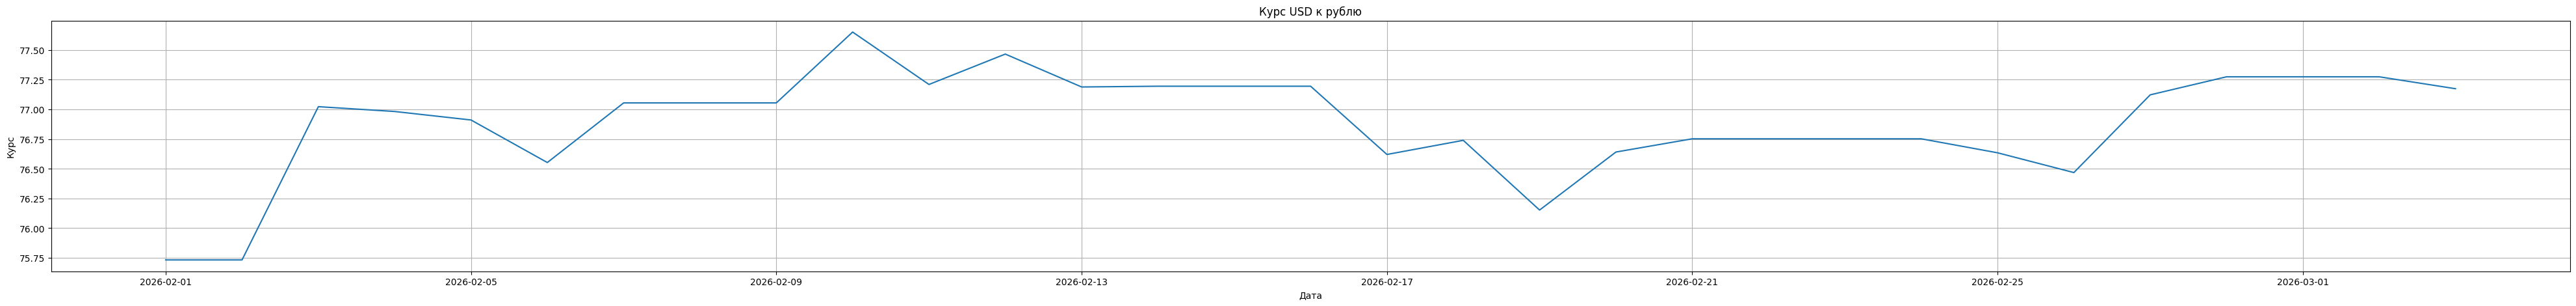

In [ ]:
import matplotlib.pyplot as plt

df = get_cbr_rates("USD", "2026-02-01", "2026-03-03")

plt.figure(figsize=(50,5))
plt.plot(df["date"], df["rate"])
plt.title("Курс USD к рублю")
plt.xlabel("Дата")
plt.ylabel("Курс")
plt.grid()
plt.show()